### PASO 5: ETIQUETADO MANUAL + REENTRENAMIENTO CON DATOS REALES

### ¿Por qué este paso?

La CNN entrenada con MNIST (incluso con augmentation) solo reconoce
bien los dígitos "gordos" (6, 8, 9). Los dígitos finos (1, 2, 3, 5, 7)
tienen una tipografía impresa muy distinta a los manuscritos de MNIST.

La solución es darle a la CNN ejemplos reales de esos dígitos.

### Plan

```
CELDA 1 → Instalaciones e imports
CELDA 2 → Extraer todas las celdas con dígito de las 170 imágenes de train
CELDA 3 → Mostrar celdas de 9 en 9 para que las etiquetes
CELDA 4 → Guardar el dataset etiquetado
CELDA 5 → Reentrenar la CNN mezclando datos reales + MNIST aumentado
CELDA 6 → Evaluar y guardar el modelo final
```

### Tiempo estimado
- Extracción de celdas (170 imágenes): ~5 min con GPU en Colab
- Etiquetado manual (~120 celdas): ~10 min [Intento 1 se etiquetaron 206 celdas, Intento 2 464 celdas, en ~10-12 minutos]
- Reentrenamiento: ~6-7 min con GPU en Colab

## CELDA 1 — Instalaciones e imports

In [1]:
# ============================================
# INSTALACIONES E IMPORTS
# ============================================

from google.colab import drive
drive.mount('/content/drive')

!pip install ultralytics tensorflow opencv-python-headless -q

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import tensorflow as tf
from tensorflow import keras
from ultralytics import YOLO
import json

RUTA_SUDOKU = '/content/drive/MyDrive/sudoku/'
RUTA_YOLO   = RUTA_SUDOKU + 'modelo_yolo.pt'
RUTA_CNN    = RUTA_SUDOKU + 'modelo_digitos_v2.keras'
RUTA_TRAIN  = RUTA_SUDOKU + 'images/train/'

# Donde guardaremos las celdas extraídas y sus etiquetas
RUTA_CELDAS = RUTA_SUDOKU + 'celdas_reales/'
os.makedirs(RUTA_CELDAS, exist_ok=True)

modelo_yolo = YOLO(RUTA_YOLO)
modelo_cnn  = keras.models.load_model(RUTA_CNN)

print("✅ Todo listo")
print(f"   TensorFlow: {tf.__version__}")
print(f"   GPU disponible: {len(tf.config.list_physical_devices('GPU')) > 0}")

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.9 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Todo listo
   TensorFlow: 2.20.0
   GPU disponible: True


#### CELDA 2 — Extraer celdas con dígito de las 170 imágenes

Recorremos todas las imágenes de train, aplicamos el warp y extraemos
solo las celdas que la CNN actual cree que tienen dígito.

Nos quedamos especialmente con las que la CNN NO reconoce bien
(confianza baja o dígitos 1, 2, 3, 5, 7) porque el modelo reconcía 6, 8 y 9.

In [2]:
# ============================================
# FUNCIONES DEL PASO 2b (necesarias para el warp)
# ============================================

def encontrar_esquinas(img_rgb, box_yolo):
    x1, y1, x2, y2 = box_yolo
    margen = 20
    H, W   = img_rgb.shape[:2]
    rx1, ry1 = max(0, x1-margen), max(0, y1-margen)
    rx2, ry2 = min(W, x2+margen), min(H, y2+margen)
    recorte  = img_rgb[ry1:ry2, rx1:rx2]
    gray     = cv2.cvtColor(recorte, cv2.COLOR_RGB2GRAY)
    blur     = cv2.GaussianBlur(gray, (5, 5), 0)
    binaria  = cv2.adaptiveThreshold(blur, 255,
                   cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                   cv2.THRESH_BINARY_INV, 11, 2)
    contornos, _ = cv2.findContours(binaria, cv2.RETR_EXTERNAL,
                                     cv2.CHAIN_APPROX_SIMPLE)
    if not contornos:
        return None
    contorno_mayor = max(contornos, key=cv2.contourArea)
    if cv2.contourArea(contorno_mayor) < 0.3 * (rx2-rx1) * (ry2-ry1):
        return None
    epsilon = 0.02 * cv2.arcLength(contorno_mayor, True)
    approx  = cv2.approxPolyDP(contorno_mayor, epsilon, True)
    intentos = 0
    while len(approx) != 4 and intentos < 10:
        epsilon *= 1.2
        approx   = cv2.approxPolyDP(contorno_mayor, epsilon, True)
        intentos += 1
    if len(approx) != 4:
        rect   = cv2.minAreaRect(contorno_mayor)
        approx = cv2.boxPoints(rect).reshape(-1, 1, 2).astype(int)
    puntos = approx.reshape(-1, 2).astype(np.float32)
    puntos[:, 0] += rx1
    puntos[:, 1] += ry1
    return puntos

def ordenar_esquinas(puntos):
    puntos  = puntos.reshape(4, 2)
    ordered = np.zeros((4, 2), dtype=np.float32)
    sumas   = puntos.sum(axis=1)
    diffs   = np.diff(puntos, axis=1).flatten()
    ordered[0] = puntos[np.argmin(sumas)]
    ordered[2] = puntos[np.argmax(sumas)]
    ordered[1] = puntos[np.argmin(diffs)]
    ordered[3] = puntos[np.argmax(diffs)]
    return ordered

def warp_perspectiva(img_rgb, esquinas, tamaño=450):
    origen  = ordenar_esquinas(esquinas)
    destino = np.float32([[0,tamaño],[tamaño,0],[tamaño,tamaño],[0,0]])
    destino = np.float32([[0,0],[tamaño,0],[tamaño,tamaño],[0,tamaño]])
    M       = cv2.getPerspectiveTransform(origen, destino)
    return cv2.warpPerspective(img_rgb, M, (tamaño, tamaño))

def segmentar_celdas(grid_warped, tamaño_celda=50, margen=4):
    # NOTA: margen+3 en la fila/columna 0 para igualar exactamente el
    # recorte que usan Paso2b/Paso5/pipeline.py en inferencia. Antes este
    # notebook usaba 'margen' constante en todas las celdas, lo que generaba
    # un mismatch train/inferencia para los dígitos del borde superior/izq.
    gray   = cv2.cvtColor(grid_warped, cv2.COLOR_RGB2GRAY)
    celdas = []
    for i in range(9):
        for j in range(9):
            y1c = i * tamaño_celda
            y2c = (i + 1) * tamaño_celda
            x1c = j * tamaño_celda
            x2c = (j + 1) * tamaño_celda
            celda = gray[y1c:y2c, x1c:x2c]
            margen_izq = margen + 3 if j == 0 else margen
            margen_arr = margen + 3 if i == 0 else margen
            celda_sin_bordes = celda[margen_arr:tamaño_celda-margen,
                                     margen_izq:tamaño_celda-margen]
            celda_28  = cv2.resize(celda_sin_bordes, (28, 28))
            celda_bin = cv2.adaptiveThreshold(
                celda_28, 255,
                cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                cv2.THRESH_BINARY_INV, 11, 4)
            kernel    = np.ones((2, 2), np.uint8)
            celda_bin = cv2.morphologyEx(celda_bin, cv2.MORPH_OPEN, kernel)
            celda_norm = celda_bin.astype('float32') / 255.0
            celdas.append(celda_norm)
    return celdas

def hay_digito(celda_norm, umbral_area=0.05):
    celda_uint8  = (celda_norm * 255).astype(np.uint8)
    contornos, _ = cv2.findContours(celda_uint8, cv2.RETR_EXTERNAL,
                                     cv2.CHAIN_APPROX_SIMPLE)
    if not contornos:
        return False
    areas = [cv2.contourArea(c) for c in contornos
             if 20 < cv2.contourArea(c) < 0.85*28*28]
    if not areas:
        return False
    return sum(areas) / (28*28) > umbral_area

print("✅ Funciones del Paso 2b cargadas")

✅ Funciones del Paso 2b cargadas


In [3]:
# ============================================
# EXTRAER CELDAS DE LAS 170 IMÁGENES
# ============================================

print("🔄 Extrayendo celdas de todas las imágenes de train...")
print("   Esto tarda ~5 minutos con GPU")
print("="*60)

imagenes = [f for f in os.listdir(RUTA_TRAIN)
            if f.endswith(('.jpg', '.png'))]
print(f"   Total imágenes: {len(imagenes)}")

# Guardaremos todas las celdas con dígito aquí
celdas_extraidas  = []   # array 28x28 de cada celda
nombres_origen    = []   # de qué imagen viene
posiciones_origen = []   # posición (i,j) en el sudoku

errores = 0

for idx_img, nombre_img in enumerate(imagenes):
    ruta = RUTA_TRAIN + nombre_img

    # YOLO detecta la cuadrícula
    try:
        results = modelo_yolo(ruta, verbose=False)
    except Exception:
        errores += 1
        continue

    if len(results[0].boxes) == 0:
        errores += 1
        continue

    box = results[0].boxes[0]
    if float(box.conf[0]) < 0.5:
        errores += 1
        continue

    x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())

    # Warp
    img     = cv2.imread(ruta)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    esquinas = encontrar_esquinas(img_rgb, (x1, y1, x2, y2))

    if esquinas is not None:
        grid_warped = warp_perspectiva(img_rgb, esquinas)
    else:
        esq_fb      = np.float32([[x1,y1],[x2,y1],[x2,y2],[x1,y2]])
        grid_warped = warp_perspectiva(img_rgb, esq_fb)

    # Segmentar las 81 celdas
    celdas = segmentar_celdas(grid_warped)

    # Guardar solo las que tienen dígito
    for idx_celda, celda in enumerate(celdas):
        if hay_digito(celda):
            i, j = idx_celda // 9, idx_celda % 9
            celdas_extraidas.append(celda)
            nombres_origen.append(nombre_img)
            posiciones_origen.append((i, j))

    if (idx_img + 1) % 20 == 0:
        print(f"   Procesadas {idx_img+1}/{len(imagenes)} imágenes "
              f"| Celdas con dígito: {len(celdas_extraidas)}")

print(f"\n✅ Extracción completada:")
print(f"   Imágenes procesadas: {len(imagenes) - errores}/{len(imagenes)}")
print(f"   Celdas con dígito extraídas: {len(celdas_extraidas)}")
print(f"   Errores (YOLO no detectó): {errores}")

🔄 Extrayendo celdas de todas las imágenes de train...
   Esto tarda ~5 minutos con GPU
   Total imágenes: 156
   Procesadas 20/156 imágenes | Celdas con dígito: 590
   Procesadas 40/156 imágenes | Celdas con dígito: 1224
   Procesadas 60/156 imágenes | Celdas con dígito: 1816
   Procesadas 80/156 imágenes | Celdas con dígito: 2441
   Procesadas 100/156 imágenes | Celdas con dígito: 2976
   Procesadas 120/156 imágenes | Celdas con dígito: 3599
   Procesadas 140/156 imágenes | Celdas con dígito: 4182

✅ Extracción completada:
   Imágenes procesadas: 156/156
   Celdas con dígito extraídas: 4697
   Errores (YOLO no detectó): 0


#### CELDA 3 — Etiquetar las celdas manualmente

Esta celda muestra las celdas de 20 en 20 con la predicción actual de la CNN.
Para cada celda hay que escribir el dígito correcto (1-9).

**Instrucciones:**
- El título de cada celda muestra lo que predice la CNN actualmente
- Si la predicción es correcta, escribe ese mismo número
- Si es incorrecta, escribe el número correcto
- Si no estás seguro, escribe 0 (se descartará)
- Si la celda aparece vacía, escribe 0
- Cada dígito debe estar separado por un espacio.

Ejecuta esta celda tantas veces como sea necesario hasta etiquetar todas. A veces es necesario ejecutar varias veces para que aparezca la casilla.   A partir de la celda 170 (aprox) aparecían más valores dudosos que cifras, como muestra el output.

✅ Continuando desde la celda 580
   Ya etiquetadas: 446

📋 Mostrando celdas 581 a 600 de 4697


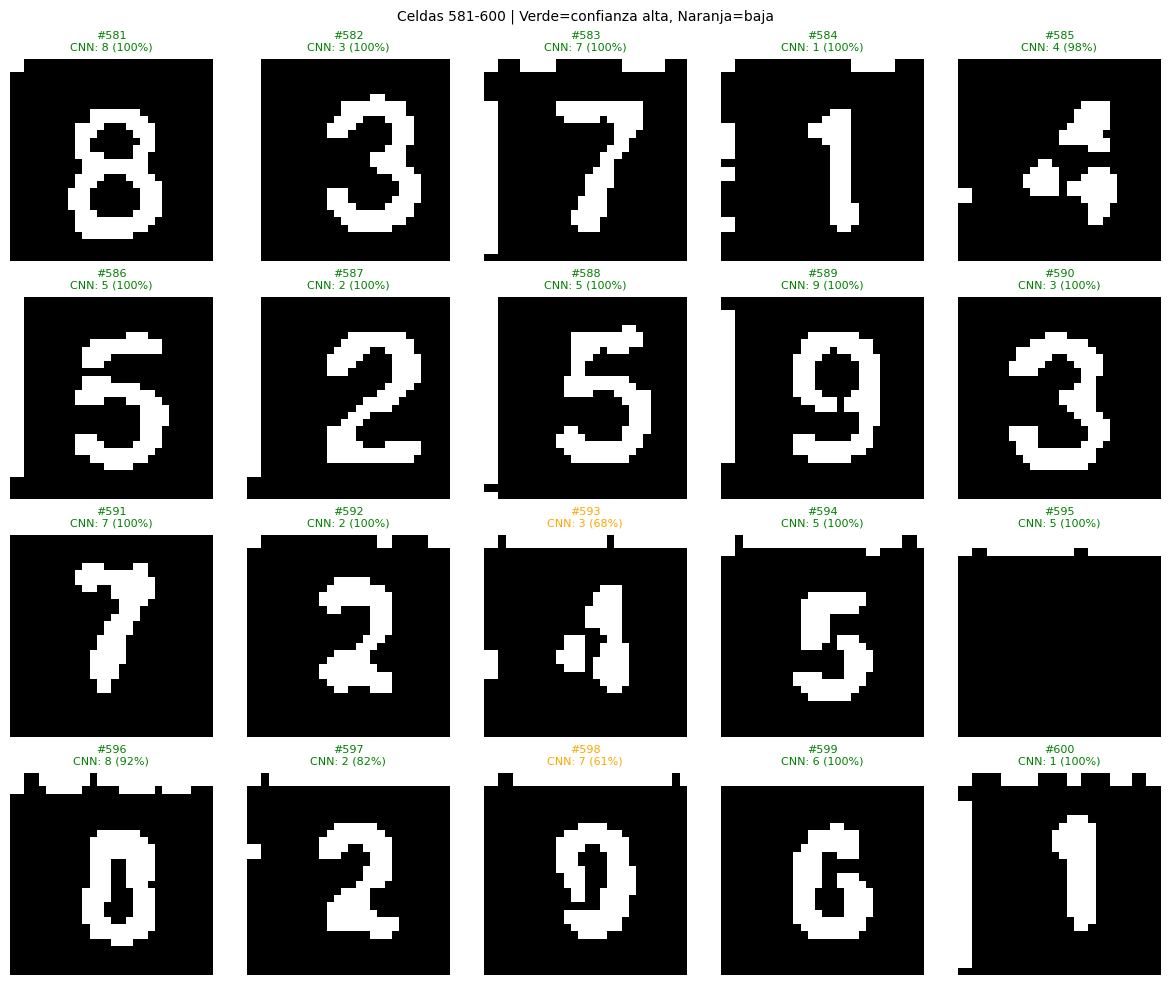


✏️  Escribe las etiquetas separadas por espacios.
   Una por celda, en el mismo orden que aparecen (fila por fila).
   Usa 0 si no estás seguro de alguna.
   Necesitas 20 números:

   Etiquetas (20 números): 8 3 7 1 4 5 2 5 9 3 7 2 4 5 0 0 2 9 6 1

✅ Bloque guardado:
   Aceptadas: 18
   Descartadas (0): 2
   Total etiquetadas hasta ahora: 464

   Quedan 4097 celdas.
   Vuelve a ejecutar esta celda para continuar.


In [70]:
# ============================================
# ETIQUETADO MANUAL — BLOQUE A BLOQUE
# ============================================

# Esta lista acumulará todas las etiquetas
# Si ya ejecutaste esta celda antes, no la resetees
if 'etiquetas' not in dir() or etiquetas is None:
    etiquetas       = []   # etiquetas confirmadas
    celdas_ok       = []   # celdas confirmadas
    idx_etiquetado  = 0    # índice actual
    print("✅ Iniciando etiquetado desde el principio")
else:
    print(f"✅ Continuando desde la celda {idx_etiquetado}")
    print(f"   Ya etiquetadas: {len(etiquetas)}")

BLOQUE = 20   # cuántas celdas mostrar a la vez

# ── Mostrar el bloque actual ─────────────────────────────────────────────
fin    = min(idx_etiquetado + BLOQUE, len(celdas_extraidas))
bloque = celdas_extraidas[idx_etiquetado:fin]

if not bloque:
    print("\n✅ ¡Todas las celdas etiquetadas!")
    print(f"   Total etiquetadas: {len(etiquetas)}")
else:
    print(f"\n📋 Mostrando celdas {idx_etiquetado+1} a {fin} "
          f"de {len(celdas_extraidas)}")

    # Predicción de la CNN para cada celda del bloque
    predicciones = []
    for celda in bloque:
        entrada = celda.reshape(1, 28, 28, 1)
        pred    = modelo_cnn.predict(entrada, verbose=0)[0]
        pred[0] = 0.0
        pred    = pred / pred.sum()
        dig     = int(np.argmax(pred))
        conf    = float(pred[dig])
        predicciones.append((dig, conf))

    # Mostrar en cuadrícula
    cols     = 5
    filas    = (len(bloque) + cols - 1) // cols
    fig, axes = plt.subplots(filas, cols, figsize=(12, filas * 2.5))
    axes     = axes.flatten()

    for k, (celda, (dig, conf)) in enumerate(zip(bloque, predicciones)):
        axes[k].imshow(celda, cmap='gray', vmin=0, vmax=1)
        color = 'green' if conf > 0.70 else 'orange'
        axes[k].set_title(f'#{idx_etiquetado+k+1}\nCNN: {dig} ({conf:.0%})',
                          fontsize=8, color=color)
        axes[k].axis('off')

    for k in range(len(bloque), len(axes)):
        axes[k].axis('off')

    plt.suptitle(f'Celdas {idx_etiquetado+1}-{fin} | '
                 f'Verde=confianza alta, Naranja=baja', fontsize=10)
    plt.tight_layout()
    plt.show()

    # ── Pedir etiquetas ──────────────────────────────────────────────────
    print("\n✏️  Escribe las etiquetas separadas por espacios.")
    print("   Una por celda, en el mismo orden que aparecen (fila por fila).")
    print("   Usa 0 si no estás seguro de alguna.")
    print(f"   Necesitas {len(bloque)} números:")
    print()

    respuesta = input(f"   Etiquetas ({len(bloque)} números): ").strip()
    valores   = respuesta.split()

    if len(valores) != len(bloque):
        print(f"\n❌ Escribiste {len(valores)} valores pero hay {len(bloque)} celdas.")
        print("   Vuelve a ejecutar esta celda sin cambiar nada.")
    else:
        try:
            valores_int = [int(v) for v in valores]

            # Guardar solo los que no son 0
            for k, (celda, etiqueta) in enumerate(zip(bloque, valores_int)):
                if 1 <= etiqueta <= 9:
                    celdas_ok.append(celda)
                    etiquetas.append(etiqueta)

            idx_etiquetado = fin
            descartadas    = sum(1 for v in valores_int if v == 0)

            print(f"\n✅ Bloque guardado:")
            print(f"   Aceptadas: {len(bloque) - descartadas}")
            print(f"   Descartadas (0): {descartadas}")
            print(f"   Total etiquetadas hasta ahora: {len(etiquetas)}")

            if idx_etiquetado < len(celdas_extraidas):
                restantes = len(celdas_extraidas) - idx_etiquetado
                print(f"\n   Quedan {restantes} celdas.")
                print("   Vuelve a ejecutar esta celda para continuar.")
            else:
                print("\n   ¡Has etiquetado todas las celdas!")
                print("   Continúa con la celda 4.")

        except ValueError:
            print("\n❌ Algún valor no es un número.")
            print("   Vuelve a ejecutar esta celda.")

#### CELDA 4 — Guardar el dataset etiquetado

In [71]:
# ============================================
# GUARDAR EL DATASET ETIQUETADO
# ============================================

if len(etiquetas) == 0:
    print("❌ No hay etiquetas guardadas todavía.")
    print("   Ejecuta la celda 3 primero.")
else:
    # Convertir a arrays numpy
    x_real = np.array(celdas_ok, dtype=np.float32)      # (N, 28, 28)
    y_real = np.array(etiquetas, dtype=np.int32)          # (N,)

    # Guardar en Drive
    np.save(RUTA_CELDAS + 'x_real.npy', x_real)
    np.save(RUTA_CELDAS + 'y_real.npy', y_real)

    print(f"✅ Dataset etiquetado guardado en: {RUTA_CELDAS}")
    print(f"   Total celdas: {len(x_real)}")

    # Mostrar distribución de clases
    print("\n📊 Distribución de dígitos etiquetados:")
    for digito in range(1, 10):
        n = int(np.sum(y_real == digito))
        barra = '█' * n
        print(f"   {digito}: {barra} ({n})")

    # Advertencia si algún dígito tiene muy pocos ejemplos
    minimo = min(int(np.sum(y_real == d)) for d in range(1, 10))
    if minimo < 10:
        digitos_escasos = [d for d in range(1, 10)
                           if int(np.sum(y_real == d)) < 10]
        print(f"\n   ⚠️ Dígitos con menos de 10 ejemplos: {digitos_escasos}")
        print(f"   Intenta etiquetar más celdas de esos dígitos")
        print(f"   (vuelve a la celda 3 y busca esos números)")
    else:
        print(f"\n   ✅ Todos los dígitos tienen al menos {minimo} ejemplos")

✅ Dataset etiquetado guardado en: /content/drive/MyDrive/sudoku/celdas_reales/
   Total celdas: 464

📊 Distribución de dígitos etiquetados:
   1: ███████████████████████████████████████████ (43)
   2: ██████████████████████████████████████████████████ (50)
   3: ██████████████████████████████████████████████████████████████ (62)
   4: ███████████████████████████████████████████████████ (51)
   5: ███████████████████████████████████████████████████████████ (59)
   6: ████████████████████████████████████████████ (44)
   7: ██████████████████████████████████████████████████ (50)
   8: █████████████████████████████████████████████████ (49)
   9: ████████████████████████████████████████████████████████ (56)

   ✅ Todos los dígitos tienen al menos 43 ejemplos


#### CELDA 5 — Reentrenar la CNN con datos reales + MNIST aumentado

Mezclamos las celdas reales etiquetadas con el dataset de MNIST aumentado.
Las celdas reales se repiten varias veces (oversampling) para compensar
que son pocas comparado con MNIST.

In [4]:
# ============================================
# REENTRENAR CNN CON DATOS REALES + MNIST
# ============================================

# ── Cargar dataset etiquetado ────────────────────────────────────────────
x_real = np.load(RUTA_CELDAS + 'x_real.npy')
y_real = np.load(RUTA_CELDAS + 'y_real.npy')
print(f"📂 Celdas reales cargadas: {len(x_real)}")

# ── Cargar y preparar MNIST (solo clases 1-9) ────────────────────────────
print("📂 Cargando MNIST...")
(x_mnist, y_mnist), _ = keras.datasets.mnist.load_data()
mask    = y_mnist > 0
x_mnist = x_mnist[mask].astype('float32') / 255.0
y_mnist = y_mnist[mask]

# ── Augmentation de MNIST ────────────────────────────────────────────────
def augmentar_digito(img_28x28):
    img = img_28x28.copy()
    img_uint8 = (img * 255).astype(np.uint8)
    kernel_size = np.random.choice([1, 2, 3])
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    if np.random.random() > 0.5:
        img_uint8 = cv2.erode(img_uint8, kernel, iterations=1)
    else:
        img_uint8 = cv2.dilate(img_uint8, kernel, iterations=1)
    img = img_uint8.astype(np.float32) / 255.0
    angulo = np.random.uniform(-5, 5)
    M      = cv2.getRotationMatrix2D((14, 14), angulo, 1.0)
    img    = cv2.warpAffine(img, M, (28, 28))
    dx = np.random.randint(-3, 3)
    dy = np.random.randint(-3, 3)
    M  = np.float32([[1, 0, dx], [0, 1, dy]])
    img = cv2.warpAffine(img, M, (28, 28))
    ruido = np.random.normal(0, 0.05, img.shape).astype(np.float32)
    return np.clip(img + ruido, 0, 1)

N_AUG = 8
print(f"\n🔄 Generando MNIST aumentado ({N_AUG}x)...")
x_aug_list, y_aug_list = [], []
for idx in range(len(x_mnist)):
    x_aug_list.append(x_mnist[idx])
    y_aug_list.append(y_mnist[idx])
    for _ in range(N_AUG):
        x_aug_list.append(augmentar_digito(x_mnist[idx]))
        y_aug_list.append(y_mnist[idx])
    if (idx + 1) % 10000 == 0:
        print(f"   {idx+1}/{len(x_mnist)}...")

x_aug = np.array(x_aug_list, dtype=np.float32)
y_aug = np.array(y_aug_list, dtype=np.int32)

# ── Oversample de celdas reales ──────────────────────────────────────────
# Repetimos las celdas reales para que tengan peso en el entrenamiento
# Sin oversampling, 200 celdas reales vs 500K de MNIST = casi invisible
N_REAL = 50   # repetir cada celda real 50 veces
x_real_aug = np.tile(x_real, (N_REAL, 1, 1))
y_real_aug = np.tile(y_real, N_REAL)

# Añadir variaciones leves a las celdas reales repetidas
x_real_var = []
for img in x_real_aug:
    ruido = np.random.normal(0, 0.03, img.shape).astype(np.float32)
    x_real_var.append(np.clip(img + ruido, 0, 1))
x_real_aug = np.array(x_real_var, dtype=np.float32)

# ── Combinar datasets ────────────────────────────────────────────────────
x_total = np.concatenate([x_aug, x_real_aug], axis=0)
y_total = np.concatenate([y_aug, y_real_aug], axis=0)

# Añadir dimensión de canal y mezclar
x_total = x_total.reshape(-1, 28, 28, 1)
idx_shuffle = np.random.permutation(len(x_total))
x_total = x_total[idx_shuffle]
y_total = y_total[idx_shuffle]

print(f"\n✅ Dataset combinado:")
print(f"   MNIST aumentado: {len(x_aug):,}")
print(f"   Celdas reales (×{N_REAL}): {len(x_real_aug):,}")
print(f"   Total: {len(x_total):,}")

# ── Construir y entrenar CNN ─────────────────────────────────────────────
print("\n🏗️  Construyendo CNN...")
modelo_final = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 1)),
    keras.layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.Flatten(),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(10, activation='softmax')
])

modelo_final.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=2, verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=4,
        restore_best_weights=True, verbose=1
    )
]

print("\n🚀 ENTRENANDO...")
history = modelo_final.fit(
    x_total, y_total,
    epochs=15,
    batch_size=256,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

📂 Celdas reales cargadas: 464
📂 Cargando MNIST...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

🔄 Generando MNIST aumentado (8x)...
   10000/54077...
   20000/54077...
   30000/54077...
   40000/54077...
   50000/54077...

✅ Dataset combinado:
   MNIST aumentado: 486,693
   Celdas reales (×50): 23,200
   Total: 509,893

🏗️  Construyendo CNN...

🚀 ENTRENANDO...
Epoch 1/15
1793/1793 ━━━━━━━━━━━━━━━━━━━━ 32s 13ms/step - accuracy: 0.9398 - loss: 0.1874 - val_accuracy: 0.9621 - val_loss: 0.1149 - learning_rate: 0.0010
Epoch 2/15
1793/1793 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9658 - loss: 0.1031 - val_accuracy: 0.9701 - val_loss: 0.0929 - learning_rate: 0.0010
Epoch 3/15
1793/1793 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9716 - loss: 0.0852 - val_accuracy: 0.9711 - val_loss: 0.0888 - learning_rate: 0.0010
Epoch 4/15
1793/1793 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9750 - loss: 0.0732 - val_accuracy: 0.9723 - val_loss: 0.0857 - learning_rate: 0.0010
Epoch 5

#### CELDA 6 — Evaluar y guardar el modelo final

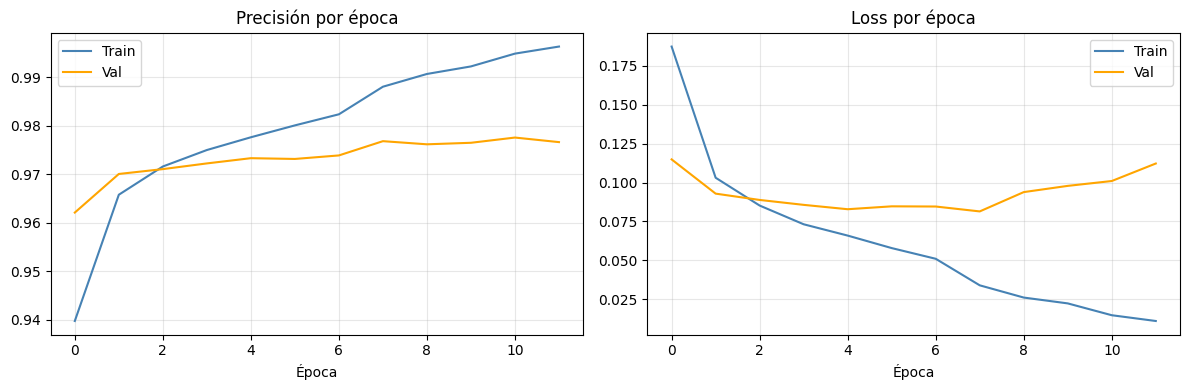


📊 Precisión en las celdas reales etiquetadas:
   464/464 correctos (100%)

📊 Por dígito:
   1: ███████████████████████████████████████████  43/43
   2: ██████████████████████████████████████████████████  50/50
   3: ██████████████████████████████████████████████████████████████  62/62
   4: ███████████████████████████████████████████████████  51/51
   5: ███████████████████████████████████████████████████████████  59/59
   6: ████████████████████████████████████████████  44/44
   7: ██████████████████████████████████████████████████  50/50
   8: █████████████████████████████████████████████████  49/49
   9: ████████████████████████████████████████████████████████  56/56

✅ Modelo guardado en: /content/drive/MyDrive/sudoku/modelo_digitos_v3.keras


In [6]:
# ============================================
# EVALUAR Y GUARDAR
# ============================================

# ── Curvas de entrenamiento ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'],     label='Train', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Val',   color='orange')
axes[0].set_title('Precisión por época')
axes[0].set_xlabel('Época')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].plot(history.history['loss'],     label='Train', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Val',   color='orange')
axes[1].set_title('Loss por época')
axes[1].set_xlabel('Época')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Probar en las celdas reales etiquetadas ──────────────────────────────
print("\n📊 Precisión en las celdas reales etiquetadas:")
x_test_real = x_real.reshape(-1, 28, 28, 1)
preds       = modelo_final.predict(x_test_real, verbose=0)
preds[:, 0] = 0.0
pred_clases = np.argmax(preds, axis=1)
aciertos    = int(np.sum(pred_clases == y_real))
print(f"   {aciertos}/{len(y_real)} correctos ({aciertos/len(y_real):.0%})")

print("\n📊 Por dígito:")
for d in range(1, 10):
    mask_d  = y_real == d
    n_total = int(np.sum(mask_d))
    if n_total == 0:
        continue
    n_ok = int(np.sum(pred_clases[mask_d] == d))
    barra = '█' * n_ok + '░' * (n_total - n_ok)
    print(f"   {d}: {barra}  {n_ok}/{n_total}")

# ── Guardar ──────────────────────────────────────────────────────────────
RUTA_MODELO_FINAL = RUTA_SUDOKU + 'modelo_digitos_v3.keras'
modelo_final.save(RUTA_MODELO_FINAL)
print(f"\n✅ Modelo guardado en: {RUTA_MODELO_FINAL}")
